# Transfer Matrix Benchmark: Vanilla BO vs Casmopolitan
This notebook benchmarks `BOTORCH_MODULAR` against `CASMOPOLITAN` on the transfer-matrix mixed search space.

The optimization target is `LUE`.
- each variation is run `n_repeats` times
- the final comparison plot shows the mean best objective with standard deviation shading


In [2]:
# Import necessary libraries
import warnings, os, sys, copy, time
os.environ['PYTHONWARNINGS'] = 'ignore'
warnings.filterwarnings('ignore')
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
    from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
    from optimpv.models.TransferMatrix.TransferMatrixAgent import TransferMatrixAgent
except Exception:
    sys.path.append('../')
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
    from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
    from optimpv.models.TransferMatrix.TransferMatrixAgent import TransferMatrixAgent

plt.style.use('default')


## Benchmark Setup


In [ ]:
# Main notebook setup
n_init = 10
total_evaluations = 22 #! * batch_size
batch_size = 2

n_repeats = 2
seed_base = 1

variations = [
    {'label': 'Vanilla BO', 'method': 'vanilla_bo'},
    {'label': 'Casmopolitan', 'method': 'casmopolitan'},
]

print(f'Total evaluations per run: {total_evaluations * batch_size}')
print(f'Repeats per variation: {n_repeats}')
print(f'Seed base: {seed_base}')
print('Variations:')
for variation in variations:
    print('  -', variation['label'])


Total evaluations per run: 44
Repeats per variation: 2
Seed base: 1
Variations:
  - Vanilla BO
  - Casmopolitan


In [4]:
# Define the parameters for the simulation
params = []

d_3 = FitParam(name='d_3', value=80e-9, bounds=[40e-9, 200e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='float', type='range', display_name='d_3', unit='m')
params.append(d_3)

d_6 = FitParam(name='d_6', value=10e-9, bounds=[5e-9, 20e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='float', type='range', display_name='d_6', unit='m')
params.append(d_6)

d_7 = FitParam(name='d_7', value=100e-9, bounds=[50e-9, 200e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='float', type='range', display_name='d_7', unit='m')
params.append(d_7)

d_8 = FitParam(name='d_8', value=10e-9, bounds=[5e-9, 20e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='float', type='range', display_name='d_8', unit='m')
params.append(d_8)

d_9 = FitParam(name='d_9', value=100e-9, bounds=[50e-9, 200e-9], log_scale=False, rescale=True, stepsize=1e-9, value_type='float', type='range', display_name='d_9', unit='m')
params.append(d_9)

nk_3 = FitParam(name='nk_3', value='PCE10_FOIC_1to1', values=['PCE10_FOIC_1to1', 'P3HTPCBM_BHJ', 'PM6Y6Brabec'], log_scale=False, rescale=False, value_type='str', type='choice', display_name='nk_3', unit='')
params.append(nk_3)

num_free_params = len([p for p in params if p.type != 'fixed'])
print(f'Number of free parameters: {num_free_params}')


Number of free parameters: 6


In [5]:
# Initialize the transfer-matrix stack
layers = ['SiOx' , 'ITO' , 'ZnO' , 'PCE10_FOIC_1to1' , 'MoOx' , 'Ag', 'MoOx', 'LiF','MoOx', 'LiF','Air']
thicknesses = [0 , 100e-9 , 30e-9 , 100e-9 , 9e-9 , 8e-9, 100e-9, 100e-9, 100e-9, 100e-9, 100e-9]
mat_dir = os.path.join(os.path.abspath('../'), 'Data', 'matdata')
lambda_min = 350e-9
lambda_max = 800e-9
lambda_step = 1e-9
x_step = 1e-9
activeLayer = 3
spectrum = os.path.join(mat_dir, 'AM15G.txt')
photopic_file = os.path.join(mat_dir, 'photopic_curve.txt')

agent = TransferMatrixAgent(
    params,
    [None],
    layers=layers,
    thicknesses=thicknesses,
    lambda_min=lambda_min,
    lambda_max=lambda_max,
    lambda_step=lambda_step,
    x_step=x_step,
    activeLayer=activeLayer,
    spectrum=spectrum,
    mat_dir=mat_dir,
    photopic_file=photopic_file,
    exp_format=['LUE'],
    metric=[None],
    loss=[None],
    threshold=[0],
    minimize=[False],
    )

In [6]:
# Optimizer builders and history extraction

def build_optimizer(variation, seed=0):

    if variation['method'] == 'vanilla_bo':
        model_kwargs_list = get_VMLC_default_model_kwargs_list(
            num_free_params=num_free_params,
            has_categorical=True,
        )
        model_kwargs_list[0] = {'seed': seed}
        models = ['SOBOL', 'BOTORCH_MODULAR']
    elif variation['method'] == 'casmopolitan':
        model_kwargs_list = [
            {'seed': seed},
            {
                'acq': 'ts',
                'n_training_steps': 100,
            },
        ]
        models = ['SOBOL', 'CASMOPOLITAN']
    else:
        raise ValueError(f"Unknown method: {variation['method']}")

    return axBOtorchOptimizer(
        params=params,
        agents=agent,
        models=models,
        n_batches=[1, total_evaluations - n_init],
        batch_size=[n_init, batch_size],
        model_kwargs_list=model_kwargs_list,
        max_parallelism=1,
        verbose_logging=False,
        name=f"transfer_matrix_{variation['method']}",
    )


def extract_history(optimizer):
    df = optimizer.ax_client._experiment.lookup_data().df.copy()
    metric_name = optimizer.all_metrics[0]
    hist = (
        df[df['metric_name'] == metric_name]
        .sort_values('trial_index')
        .loc[:, ['trial_index', 'mean']]
        .reset_index(drop=True)
    )
    hist['evaluation'] = np.arange(1, len(hist) + 1)
    hist['best_obj_val'] = np.maximum.accumulate(hist['mean'].to_numpy())
    return hist, metric_name


def extract_trial_parameters(optimizer):
    trial_rows = []
    for trial in optimizer.ax_client._experiment.trials.values():
        if hasattr(trial, 'arm') and trial.arm is not None:
            trial_rows.append(dict(trial.arm.parameters))
    return pd.DataFrame(trial_rows)


def run_variation(variation, seed=0):
    optimizer = build_optimizer(variation=variation, seed=seed)
    start_time = time.time()
    optimizer.optimize()
    runtime = time.time() - start_time
    history, metric_name = extract_history(optimizer)
    trial_params = extract_trial_parameters(optimizer)
    return {
        'label': variation['label'],
        'history': history,
        'metric_name': metric_name,
        'runtime': runtime,
        'best_value': float(history['best_obj_val'].iloc[-1]),
        'trial_params': trial_params,
        'optimizer': optimizer,
    }


def combine_runs(label, runs_for_variation):
    history_mean = pd.DataFrame({'evaluation': runs_for_variation[0]['history']['evaluation']})

    run_cols = []
    for idx, run in enumerate(runs_for_variation):
        col = f'run_{idx}'
        history_mean[col] = run['history']['best_obj_val'].to_numpy()
        run_cols.append(col)

    history_mean['mean_best_obj_val'] = history_mean[run_cols].mean(axis=1)
    history_mean['std_best_obj_val'] = history_mean[run_cols].std(axis=1)

    final_best_values = [run['best_value'] for run in runs_for_variation]
    runtimes = [run['runtime'] for run in runs_for_variation]
    pooled_trials = pd.concat(
        [run['trial_params'].assign(repeat_idx=idx) for idx, run in enumerate(runs_for_variation)],
        ignore_index=True,
    )

    return {
        'label': label,
        'runs': runs_for_variation,
        'history_mean': history_mean,
        'pooled_trials': pooled_trials,
        'mean_runtime': float(np.mean(runtimes)),
        'mean_best_obj_val': float(np.mean(final_best_values)),
        'standard_deviation': float(np.std(final_best_values)),
    }


## Run Repeated Benchmark


In [7]:
all_runs = []
for variation in variations:
    variation_runs = []
    for repeat_idx in range(n_repeats):
        seed = seed_base + repeat_idx
        print(f"Running {variation['label']} | repeat {repeat_idx + 1}/{n_repeats} | seed={seed}")
        variation_runs.append(run_variation(variation, seed=seed))
    all_runs.append({'label': variation['label'], 'runs': variation_runs})


Running Vanilla BO | repeat 1/2 | seed=1
Running Vanilla BO | repeat 2/2 | seed=2
Running Casmopolitan | repeat 1/2 | seed=1
Running Casmopolitan | repeat 2/2 | seed=2


In [8]:
combined_runs = []
for group in all_runs:
    combined_runs.append(combine_runs(group['label'], group['runs']))


In [9]:
summary_df = pd.DataFrame(
    {
        'variation': run['label'],
        'mean_runtime': run['mean_runtime'],
        'mean_best_obj_val': run['mean_best_obj_val'],
        'standard_deviation': run['standard_deviation'],
    }
    for run in combined_runs
).sort_values('mean_best_obj_val', ascending=False).reset_index(drop=True)

summary_df


,variation,mean_runtime,mean_best_obj_val,standard_deviation
0,Vanilla BO,438.543613,68.005532,1.596964
1,Casmopolitan,183.524960,67.312432,0.451470


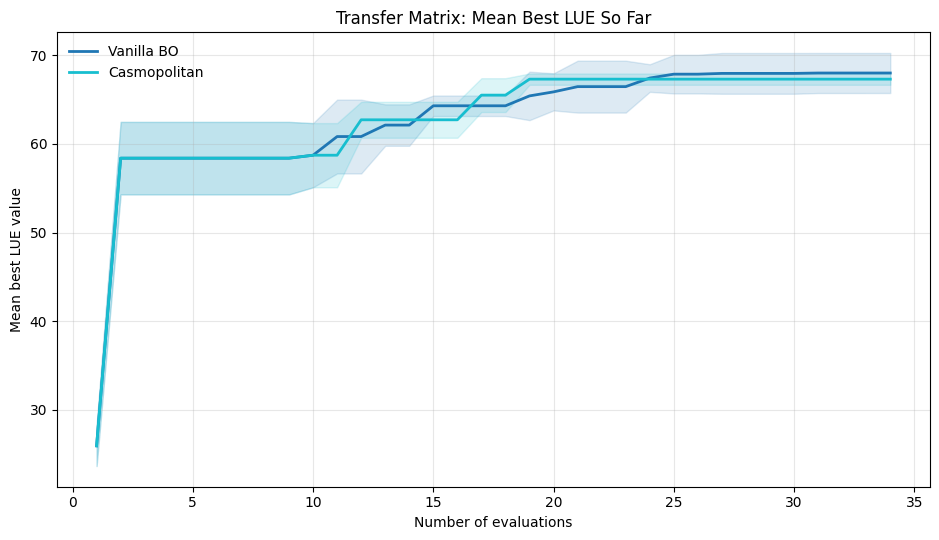

In [10]:
# Plot mean optimization comparison with standard-deviation shading
colors = plt.get_cmap('tab10')(np.linspace(0, 1, len(combined_runs)))

fig, ax = plt.subplots(figsize=(9.5, 5.5))

for color, run in zip(colors, combined_runs):
    hist = run['history_mean']
    mean_vals = hist['mean_best_obj_val']
    std_vals = hist['std_best_obj_val']

    ax.plot(
        hist['evaluation'],
        mean_vals,
        color=color,
        lw=2.0,
        label=run['label'],
    )

    ax.fill_between(
        hist['evaluation'],
        mean_vals - std_vals,
        mean_vals + std_vals,
        color=color,
        alpha=0.15,
    )

ax.set_title('Transfer Matrix: Mean Best LUE So Far')
ax.set_xlabel('Number of evaluations')
ax.set_ylabel('Mean best LUE value')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', frameon=False)

plt.tight_layout()
plt.show()


## Exploration Summary

For parameter exploration, the density plots are shown per variation and per run so the exploration behavior is visible.

The `nk_3` choice summary is aggregated as mean count per run.

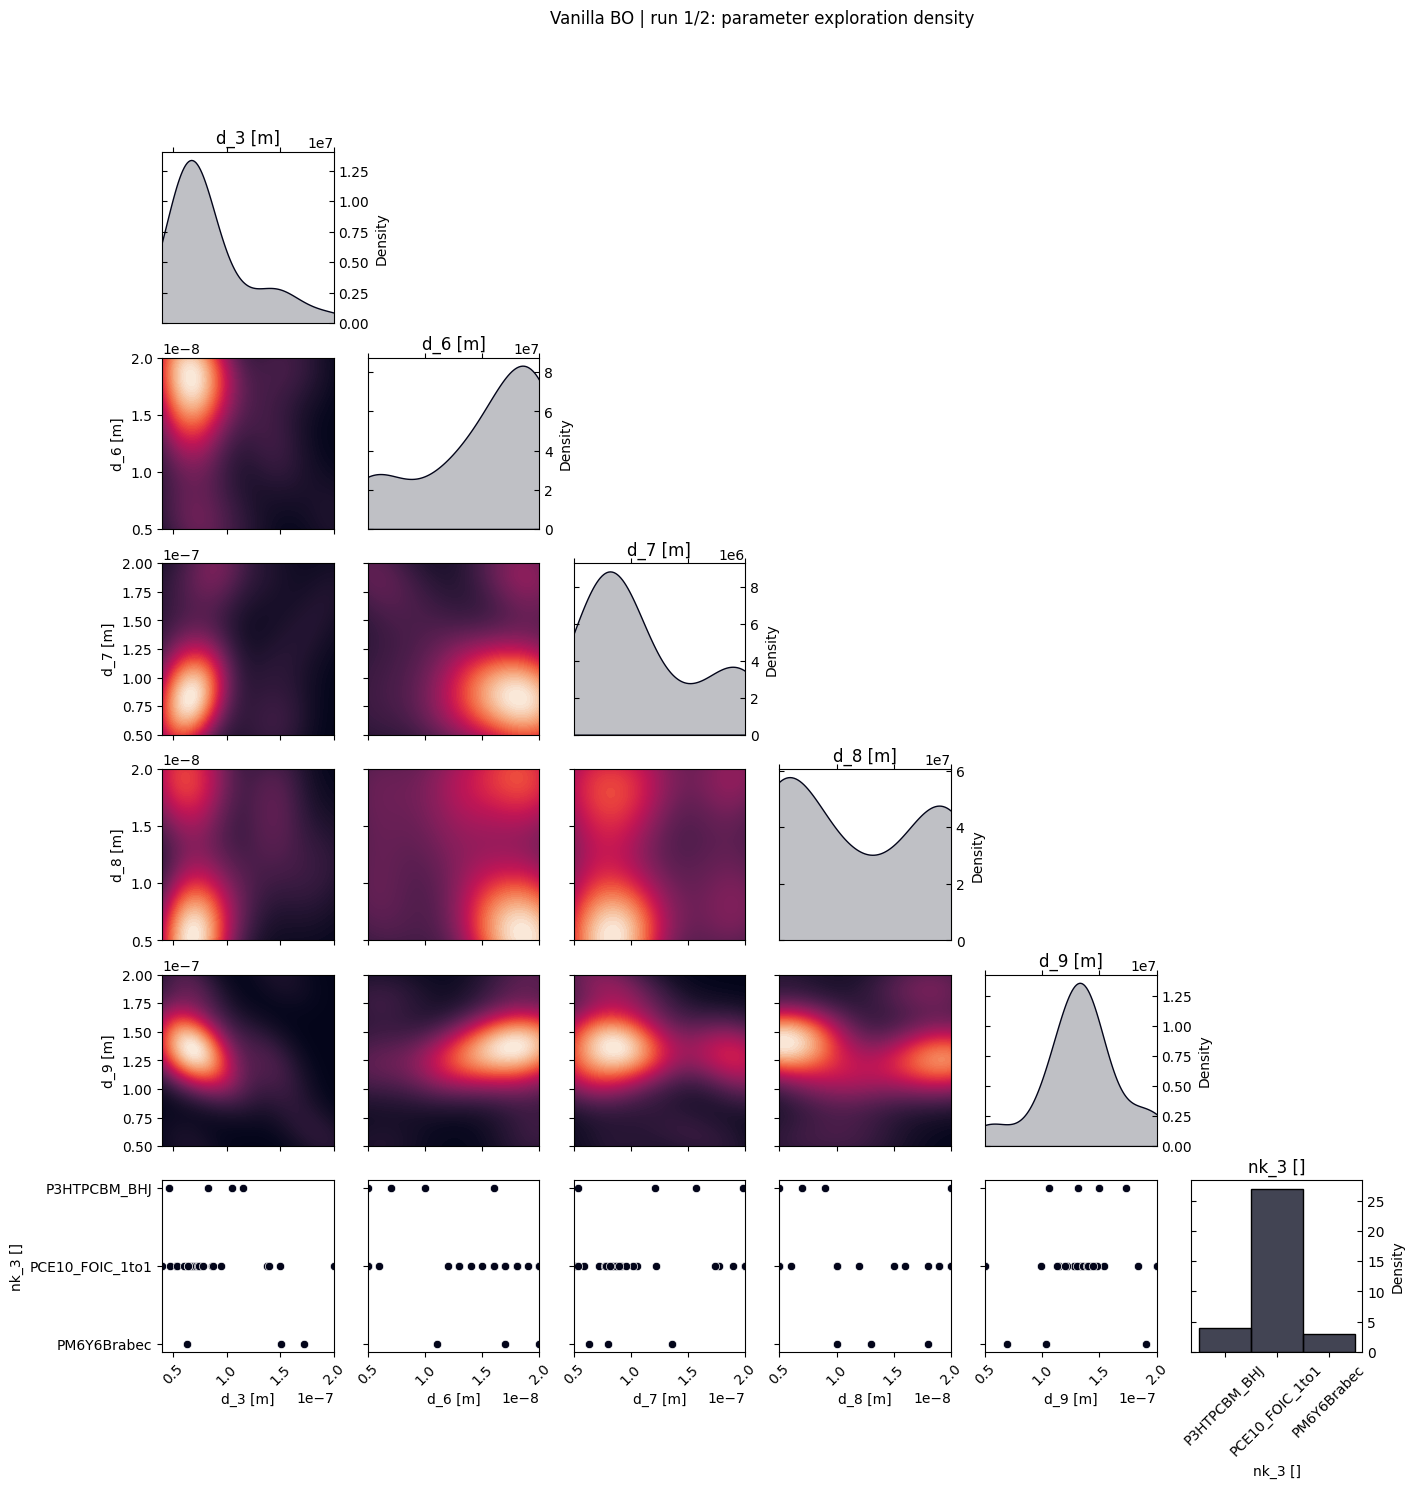

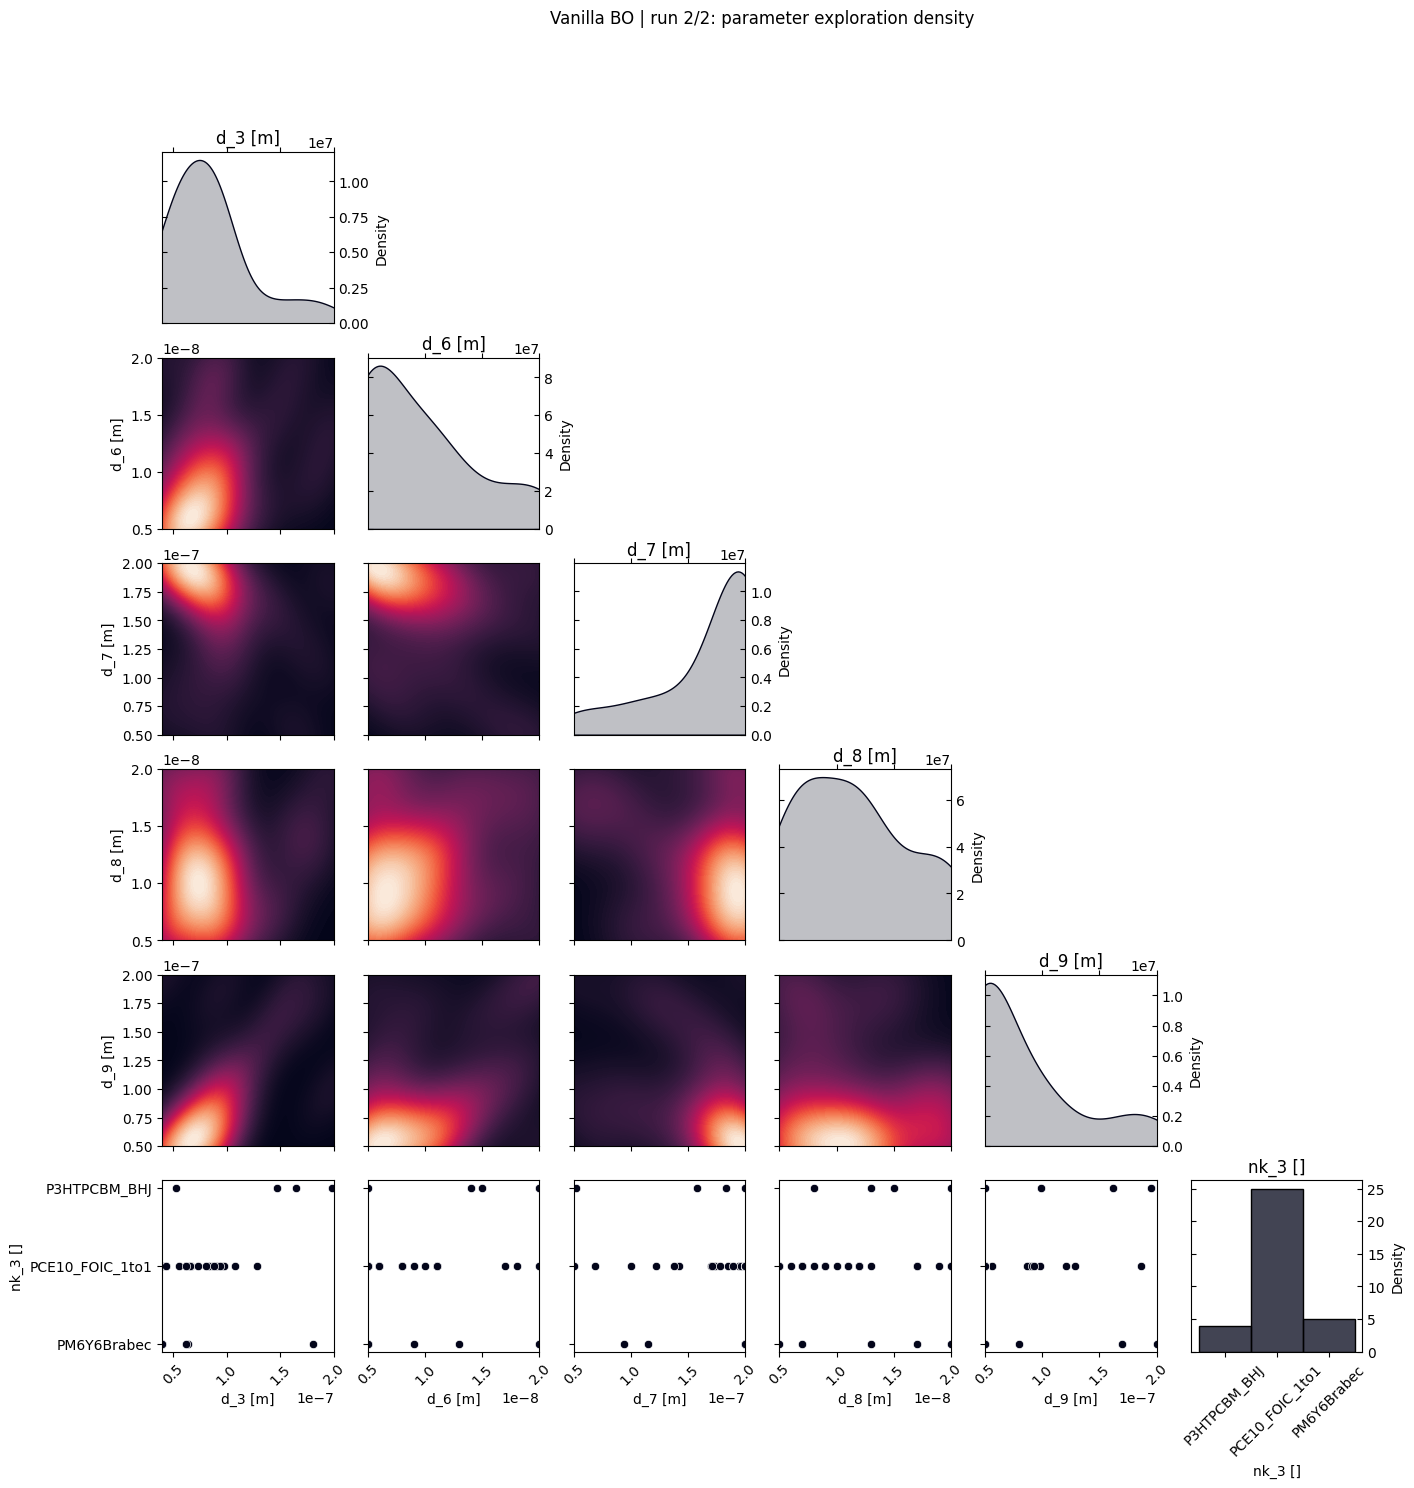

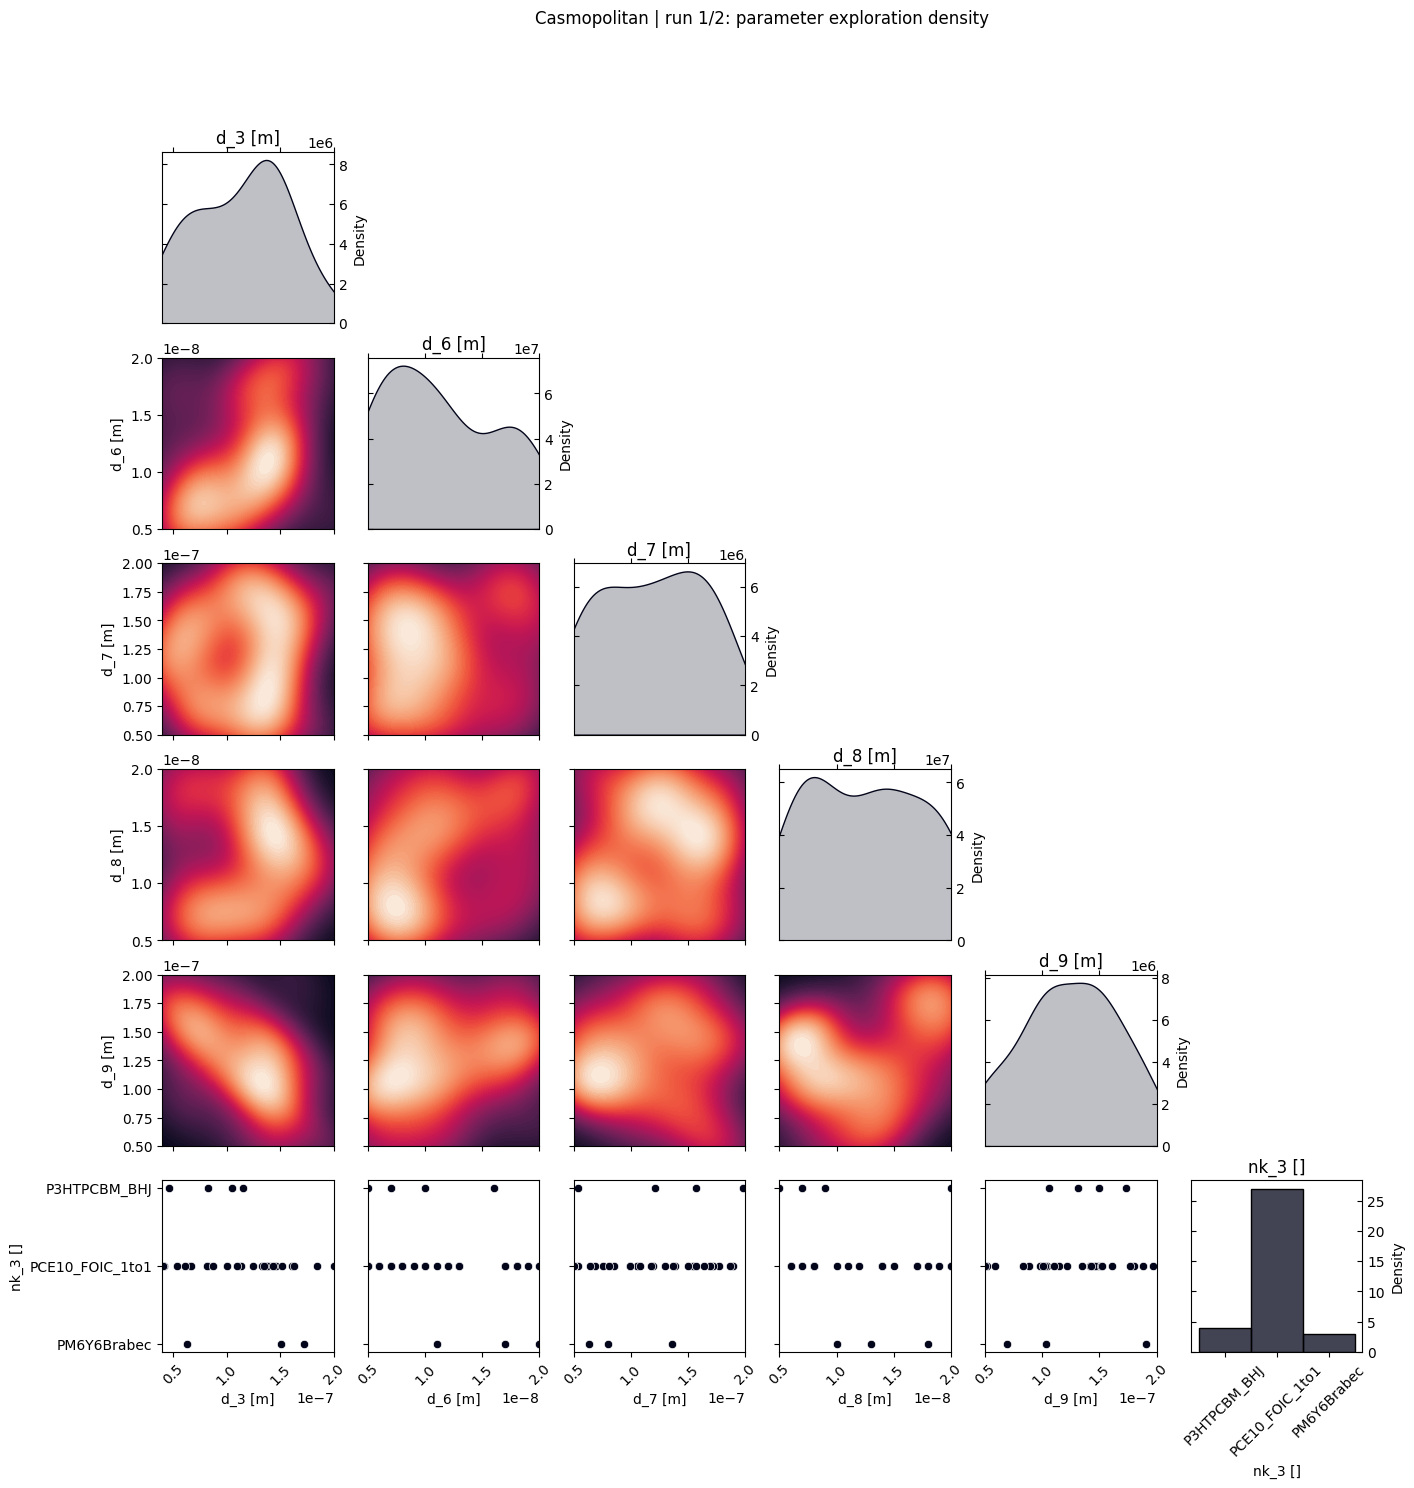

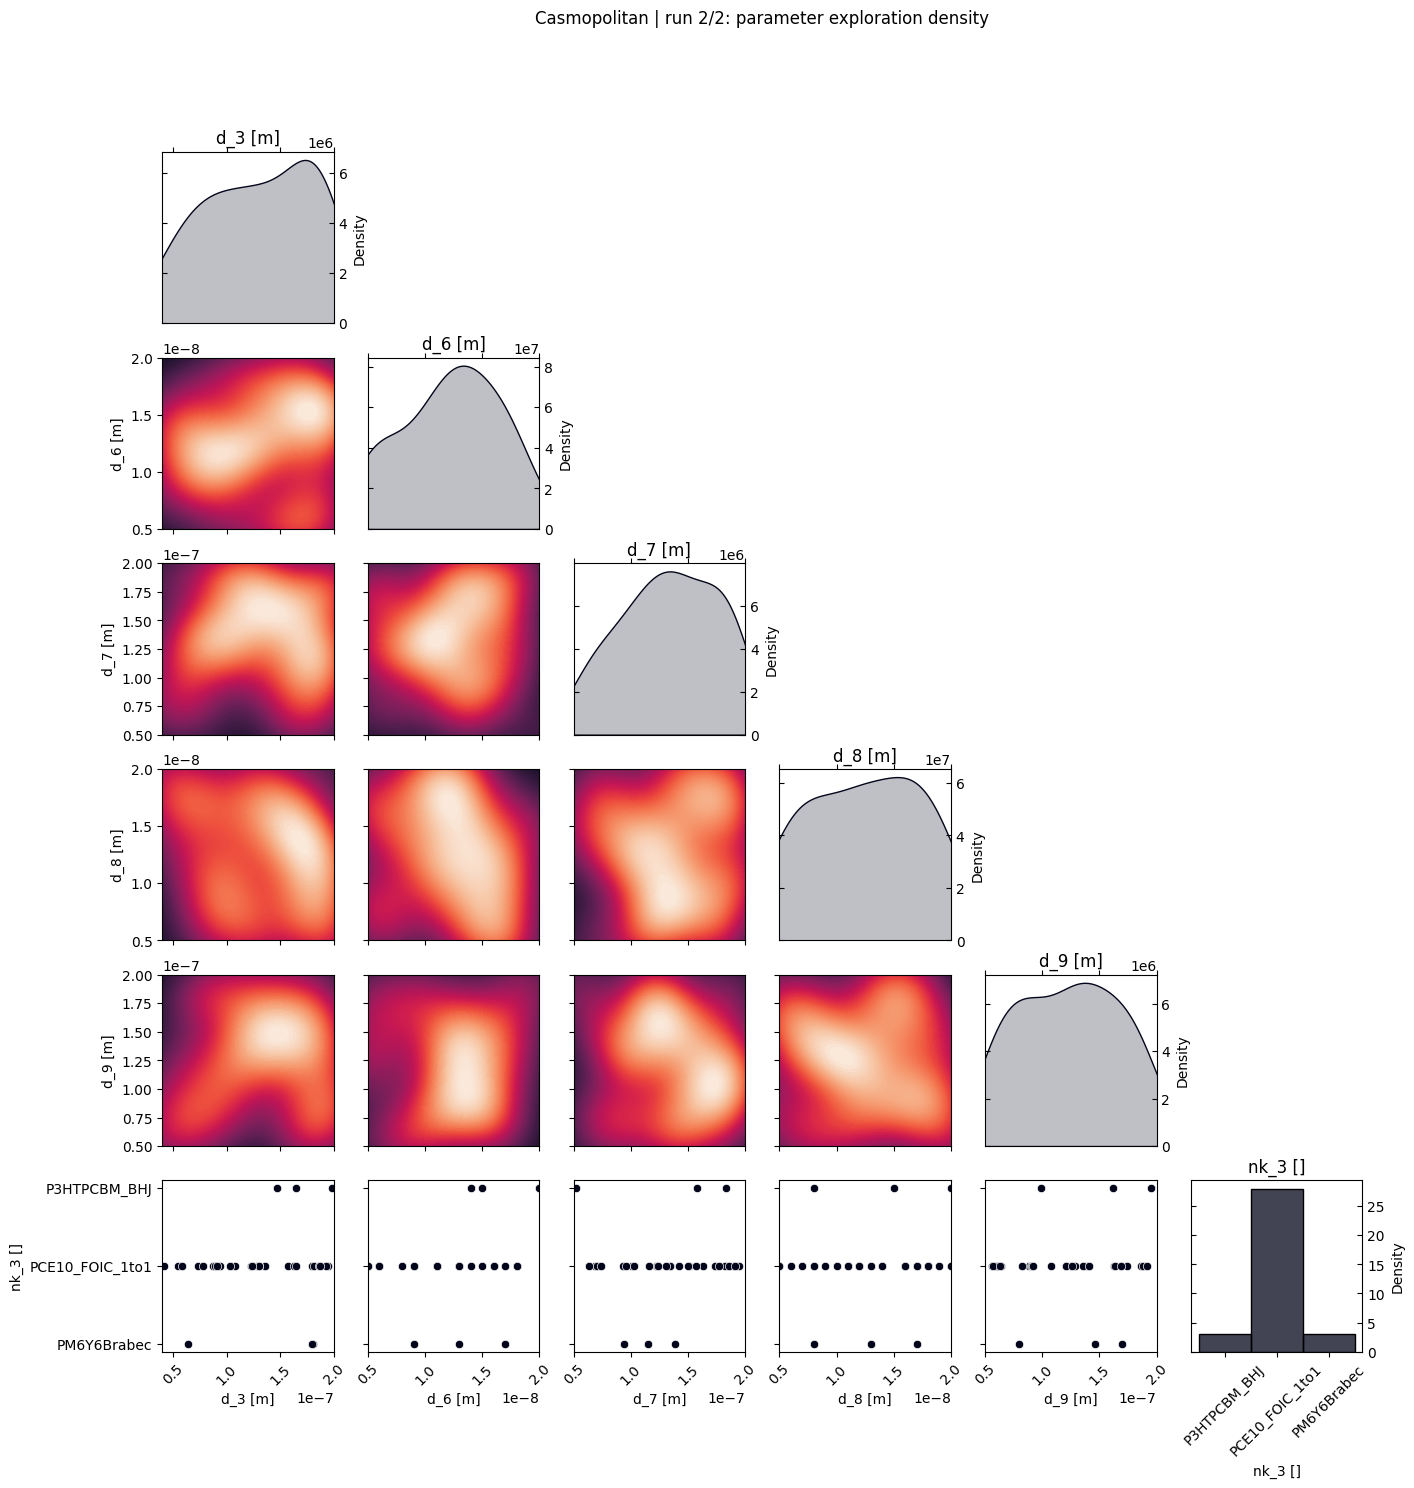

In [11]:
# Plot the exploration density for each variation and each run
from optimpv.posterior.exploration_density import plot_density_exploration

for variation_group in all_runs:
    for repeat_idx, run in enumerate(variation_group['runs']):
        fig_dens, ax_dens = plot_density_exploration(
            params,
            optimizer=run['optimizer'],
            optimizer_type='ax',
        )
        fig_dens.suptitle(
            f"{variation_group['label']} | run {repeat_idx + 1}/{n_repeats}: parameter exploration density",
            y=0.995,
        )
        plt.show()


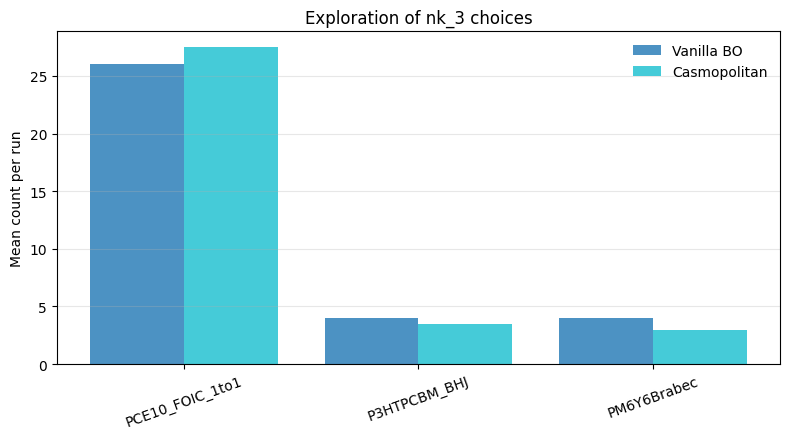

In [12]:
# Plot how often each active-material choice was explored on average per run
choice_order = next(p.values for p in params if p.name == 'nk_3')
x = np.arange(len(choice_order))
width = 0.8 / len(combined_runs)

fig, ax = plt.subplots(figsize=(8, 4.5))

for idx, (color, run) in enumerate(zip(colors, combined_runs)):
    counts = run['pooled_trials']['nk_3'].value_counts().reindex(choice_order, fill_value=0)
    mean_counts = counts / n_repeats
    offsets = x - 0.4 + width / 2 + idx * width
    ax.bar(offsets, mean_counts.values, width=width, color=color, alpha=0.8, label=run['label'])

ax.set_xticks(x)
ax.set_xticklabels(choice_order, rotation=20)
ax.set_ylabel('Mean count per run')
ax.set_title('Exploration of nk_3 choices')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='best', frameon=False)

plt.tight_layout()
plt.show()
